In [86]:

import matplotlib.pyplot as plt
import torch
import torch.utils.data as data

from torch import Tensor
torch.set_default_dtype(torch.float64)


In [87]:
def two_moons(n: int, sigma: float = 1e-1) -> tuple[Tensor, Tensor]:
    theta = 2 * torch.pi * torch.rand(n)
    label = (theta > torch.pi).float()

    x = torch.stack(
        (
            torch.cos(theta) + label - 1 / 2,
            torch.sin(theta) + label / 2 - 1 / 4,
        ),
        axis=-1,
    )

    return torch.normal(x, sigma), label


X, Y = two_moons(200)

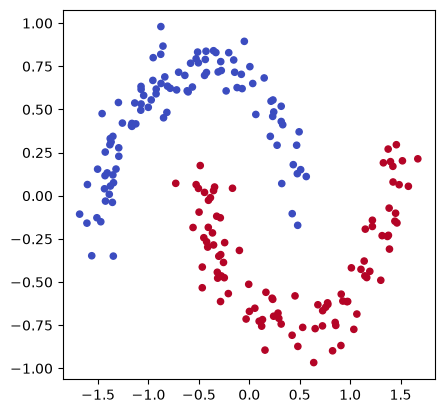

In [88]:
plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)

In [89]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from math import *


In [90]:
torch.manual_seed(7777)

m, n = X.shape
h = 20  # num. hidden units per layer
k = 1  # num. of output unit


class Model(nn.Module):
    
    def __init__(self):
        super(Model, self).__init__()

        self.feature_map = nn.Sequential(
            nn.Linear(n, h),
            nn.BatchNorm1d(h),
            nn.ReLU(), 
            nn.Linear(h, h), 
            nn.BatchNorm1d(h),
            nn.ReLU()
        )

        self.clf = nn.Linear(h, 1, bias=False)
    
    def forward(self, x):
        x = self.feature_map(x)
        return self.clf(x)
    
    
X_train = X
y_train = Y
    
model = Model()
opt = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)

for it in range(5000):
    y_pred = model(X_train).squeeze()
    l = F.binary_cross_entropy_with_logits(y_pred, y_train)
    l.backward()
    opt.step()
    opt.zero_grad()
        
print(f'Loss: {l.item():.3f}')

Loss: 0.005


In [91]:
x1 = torch.linspace(-5, 5, 100)
x2 = torch.linspace(-5, 5, 100)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

X_test = torch.stack((X1.flatten(), X2.flatten()), dim=-1)

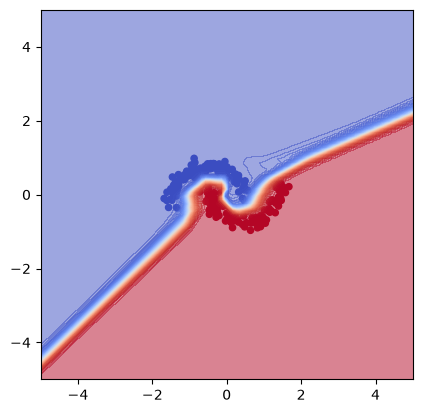

In [92]:
model.eval()

def sigmoid(x):
    return 1/(1+np.exp(-x))

with torch.no_grad():
    model.eval()
    py = sigmoid(model(X_test).squeeze().numpy())
    
conf = np.maximum(py, 1-py)

plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)
plt.contourf(X1, X2, py.reshape(X1.shape), levels=100, cmap="coolwarm", alpha=0.5)

C:\Users\stoennis\AppData\Local\Temp\ipykernel_18652\2433527366.py:56: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, X2, conf.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)


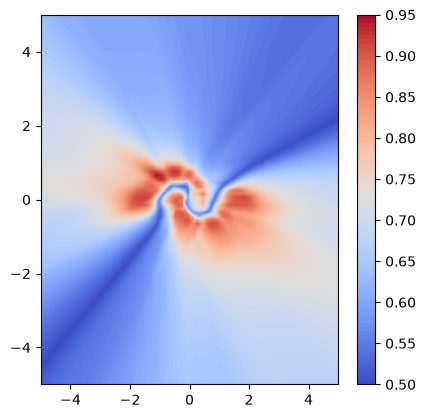

In [93]:
# Exact Hessian using PyTorch's autograd. Credits due to Felix Dangel.
from hessian import exact_hessian


W = list(model.parameters())[-1]
shape_W = W.shape

w_map = W.view(-1).data.numpy()


def neg_log_posterior(var0):
    # Negative-log-likelihood
    nll = F.binary_cross_entropy_with_logits(model(X_train).squeeze(), y_train, reduction='sum')
    # Negative-log-prior
    nlp = 1/2 * W.flatten() @ (1/var0 * torch.eye(W.numel())) @ W.flatten()
    
    return nll + nlp


def get_covariance(var0):
    # Outputs the inverse-Hessian of the negative-log-posterior at the MAP estimate
    # This is the posterior covariance
    loss = neg_log_posterior(var0)
    Lambda = exact_hessian(loss, [W])  # The Hessian of the negative log-posterior
    Sigma = torch.inverse(Lambda).detach().numpy()
    
    return Sigma


@torch.no_grad()
def predict(x, Sigma):    
    phi = model.feature_map(x).numpy()  # Feature vector of x
    m = phi @ w_map  # MAP prediction

    # "Moderate" the MAP prediction using the variance (see MacKay 1992 "Evidence Framework ...")
    # This is an approximation of the expected sigmoid (the so-called "probit approximation")
    v = np.diag(phi @ Sigma @ phi.T)
    py = sigmoid(m/np.sqrt(1 + pi/8 * v))
        
    return py


# The weight decay used for training is the Gaussian prior's precision
# Here we work in term of variance, which is just 1/precision.
var0 = 1/5e-4 

# Get the posterior covariance and make prediction
Sigma = get_covariance(var0)
py = predict(X_test, Sigma)

conf = np.maximum(py, 1-py)

plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)
# plt.contourf(X1, X2, py.reshape(X1.shape), levels=100, cmap="coolwarm", alpha=0.5)
plt.contourf(X1, X2, conf.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)
plt.colorbar()


In [94]:
import math

import pyro

import pyro.distributions as dist
from pyro.infer import SVI, Predictive, Trace_ELBO
from pyro.infer.autoguide import AutoLaplaceApproximation, init_to_value

from dataclasses import dataclass

In [95]:
class BayesianMLP(pyro.nn.PyroModule):
    def __init__(self, n, h, prior_scale=1.0):
        super(BayesianMLP, self).__init__()
        self.feature_map = nn.Sequential(
                    nn.Linear(n, h),
                    nn.BatchNorm1d(h),
                    nn.ReLU(), 
                    nn.Linear(h, h), 
                    nn.BatchNorm1d(h),
                    nn.ReLU()
                )
        self.prior_scale = prior_scale
        self._guide = AutoLaplaceApproximation(self.model, init_loc_fn=init_to_value(values={"w": torch.randn(h)}))

    def model(self, x, y):
        phi = self.feature_map(x)
        w_prior = pyro.sample("w", dist.Normal(torch.zeros(h), torch.ones(h)*self.prior_scale).to_event(1))

        logits = phi @ w_prior
        pyro.deterministic("logits", logits)
        with pyro.plate("data", x.shape[0]):
            pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
            
    def guide(self, x, y):
        return self._guide(x, y)


In [96]:
LOG_EVERY = 1000
N_STEPS = 10000

In [97]:

def linear_ramp(
    step: int,
    n_steps: int,
    *,
    start: float = 0.0,
    end: float = 1.0,
) -> float:
    """Interpolate linearly from *start* to *end* over *n_steps*, clamped outside.

    ``step <= 0`` returns *start* and ``step >= n_steps`` returns *end*, so the
    ramp can be offset by passing a shifted step.  ``n_steps <= 0`` disables the
    ramp and returns *end* immediately.
    """
    if n_steps <= 0:
        return end
    frac = min(max(step / n_steps, 0.0), 1.0)
    return start + frac * (end - start)


@dataclass(frozen=True)
class TrainingSchedule:
    """SVI loop length, logging cadence, and the KL annealing ramp.

    KL annealing multiplies the KL term by a factor that is held at *kl_start*
    for *kl_warmup_steps*, then grows linearly to 1 over *kl_anneal_steps*.
    Early training is therefore driven almost entirely by the likelihood, which
    is what stops the guide from collapsing onto the prior before it has fit any
    signal — the failure mode that leaves a converged loss at 0.5 accuracy.

    *kl_start* must stay strictly positive: ``poutine.scale`` rejects a zero
    scale.  Leaving *kl_anneal_steps* at 0 disables annealing (KL weight 1
    throughout), i.e. the plain ELBO.
    """

    n_steps: int = N_STEPS
    log_every: int = LOG_EVERY
    kl_warmup_steps: int = 0
    kl_anneal_steps: int = 0
    kl_start: float = 1e-3

    def kl_scale(self, step: int) -> float:
        """Return the KL weight for 1-based *step*."""
        return linear_ramp(
            step - self.kl_warmup_steps,
            self.kl_anneal_steps,
            start=self.kl_start,
            end=1.0,
        )


def train(
    svi: SVI,
    x_train: torch.Tensor,
    y_train: torch.Tensor,
    schedule: TrainingSchedule,
) -> tuple[list[float], list[float]]:
    """Run an SVI training loop and return the per-step (loss, KL weight) history.

    The caller is responsible for constructing *svi* (model, guide, optimizer,
    and loss bundled together) and for clearing the Pyro param store beforehand
    if separate calls should not share parameter state.

    Losses are per-datapoint whenever the model was built with
    ``elbo_scale=1/n_train``, and are computed against the *annealed* objective,
    so they are only comparable across steps once the KL weight reaches 1.
    """
    losses: list[float] = []
    kl_scales: list[float] = []
    for step in range(1, schedule.n_steps + 1):
        kl_scale = schedule.kl_scale(step)
        loss = svi.step(x_train, y_train)
        losses.append(loss)
        kl_scales.append(kl_scale)
        if step % schedule.log_every == 0:
            print(
                f"    step {step:>6}/{schedule.n_steps}"
                f"  ELBO/point: {loss:>12.5f}"
                f"  KL weight: {kl_scale:>7.4f}"
            )

    return losses, kl_scales

In [98]:

from pyro.infer import TraceMeanField_ELBO
from pyro.optim import ClippedAdam

pyro.clear_param_store()

schedule = TrainingSchedule()

initial_lr = 0.001
gamma = 0.1  # final learning rate will be gamma * initial_lr
lrd = gamma ** (1 / schedule.n_steps)

BNN = BayesianMLP(
        n=n,
        h=h,
        prior_scale=1.0,
    )

svi = SVI(
        BNN.model,
        BNN.guide,
        # ClippedAdam, not plain Adam: only it accepts `lrd` (per-step LR decay),
        # and its gradient clipping is a cheap guard against the occasional huge
        # step out of a bad init.  `eps` sits below the normalized gradient
        # magnitudes so Adam stays scale invariant and `initial_lr` keeps the
        # meaning it had before ELBO normalization.
        ClippedAdam({"lr": initial_lr, "lrd": lrd, "eps": 1e-12, "clip_norm": 10.0}),
        loss=TraceMeanField_ELBO(num_particles=1, vectorize_particles=True),
    )

losses, _ = train(svi, X_train, y_train, schedule)

    step   1000/10000  ELBO/point:     99.04429  KL weight:  1.0000
    step   2000/10000  ELBO/point:     67.50032  KL weight:  1.0000
    step   3000/10000  ELBO/point:     57.72799  KL weight:  1.0000
    step   4000/10000  ELBO/point:     52.54554  KL weight:  1.0000
    step   5000/10000  ELBO/point:     49.61872  KL weight:  1.0000
    step   6000/10000  ELBO/point:     47.97244  KL weight:  1.0000
    step   7000/10000  ELBO/point:     47.07848  KL weight:  1.0000
    step   8000/10000  ELBO/point:     46.61297  KL weight:  1.0000
    step   9000/10000  ELBO/point:     46.37927  KL weight:  1.0000
    step  10000/10000  ELBO/point:     46.26502  KL weight:  1.0000


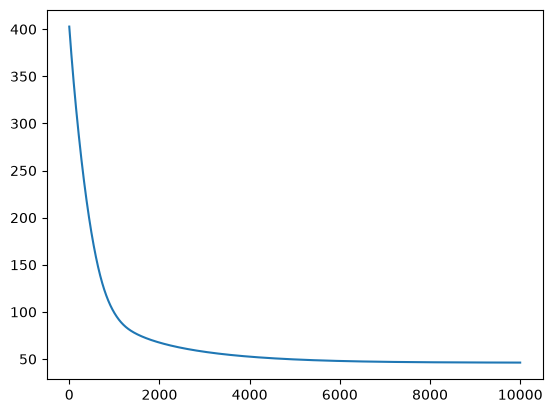

In [100]:
plt.plot(losses)

In [103]:
# x1 = torch.linspace(-10, 10, 100)
# x2 = torch.linspace(-10, 10, 100)
# X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

#  = torch.stack((X1.flatten(), X2.flatten()), dim=-1)

guide = BNN._guide.laplace_approximation(X_train, y_train)
predictive = Predictive(
    BNN.model,
    guide=guide,
    num_samples=1000,
    return_sites=("logits",),
)

samples = predictive(X_test, None)
logits = samples["logits"] # .mean(dim=0).reshape(X1.shape)

conf = np.maximum(logits.sigmoid().detach().numpy(), 1-logits.sigmoid().detach().numpy())

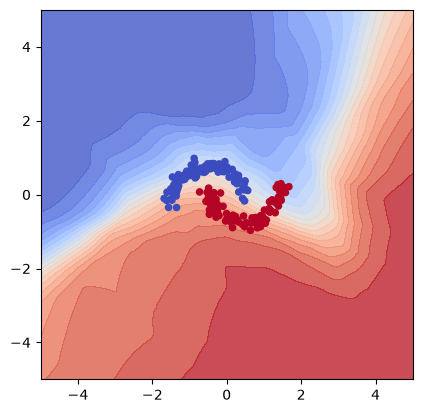

In [105]:

plt.figure(figsize=(4.8, 4.8))
plt.contourf(X1, X2, logits.sigmoid().mean(dim=0).reshape(X1.shape).detach().numpy(), levels=20, cmap="coolwarm", alpha=0.8)
# plt.contourf(X1, X2, conf.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)

## Last-layer Laplace in Pyro

Same recipe as `bnn_laplace.ipynb`, but the Laplace step is done by
`AutoLaplaceApproximation` instead of an explicit Hessian.

Three things have to line up for the scaling to be right:

1. **The feature map is fixed and frozen.** Only $w^L$ is a latent variable.
   The Pyro model must reuse the *MAP-trained* `model.feature_map`, with
   `model.eval()` (BatchNorm in eval mode) and `requires_grad_(False)`.
2. **The prior is a scale, not a variance.** The weight decay $\lambda$ is
   the prior *precision*, so `prior_scale` $=\sqrt{1/\lambda}$.
3. **The likelihood is summed over the full dataset** (no `poutine.scale`,
   no subsampling), so that the log joint Pyro differentiates is exactly
   $-\log p(w^L \mid D)$ and the Hessian has the right magnitude.

In [12]:
import math

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Predictive, Trace_ELBO
from pyro.infer.autoguide import AutoLaplaceApproximation, init_to_value

c:\Users\stoennis\Desktop\UQHM\github\last_layer_laplace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Freeze the MAP-trained feature map

`model` was trained above with `weight_decay=5e-4`; that weight decay *is* the
Gaussian prior precision on the last layer.

In [13]:
WEIGHT_DECAY = 5e-4          # == prior precision
prior_var = 1.0 / WEIGHT_DECAY
prior_scale = math.sqrt(prior_var)   # dist.Normal wants a *scale* (std)

model.eval()                 # BatchNorm -> running stats, not batch stats
for p in model.parameters():
    p.requires_grad_(False)

w_map = model.clf.weight.detach().reshape(-1).clone()   # (h,)


@torch.no_grad()
def features(x: Tensor) -> Tensor:
    return model.feature_map(x)


print(f"prior_scale = {prior_scale:.3f}, w_map.shape = {tuple(w_map.shape)}")

prior_scale = 44.721, w_map.shape = (20,)


### The Bayesian last layer

Only `w` is sampled. `phi @ w.unsqueeze(-1)` broadcasts correctly both with and
without a leading sample dimension, which is what makes `Predictive` work later.

In [14]:
def ll_model(x: Tensor, y: Tensor | None = None) -> None:
    phi = features(x)                                  # (N, h), fixed
    w = pyro.sample("w", dist.Normal(torch.zeros(h), prior_scale).to_event(1))
    logits = (phi @ w.unsqueeze(-1)).squeeze(-1)       # (..., N)
    pyro.deterministic("logits", logits)
    with pyro.plate("data", x.shape[0]):
        pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

### Fit

`AutoLaplaceApproximation` is a two-stage guide: SVI with a `Delta` guide finds
the MAP of *this* model, then `.laplace_approximation()` returns an
`AutoMultivariateNormal` whose covariance is the inverse Hessian of the negative
log joint at that point.

Initialising at `w_map` means the SVI stage only has to polish. It does move a
little: SGD minimised the *mean* BCE plus $\tfrac{\lambda}{2}\|w\|^2$, which is
the MAP for prior variance $1/(N\lambda)$, whereas this model's prior variance is
$1/\lambda$. Pyro finds the MAP of the model we actually wrote down, so use
`guide`'s `loc` (not `w_map`) for prediction.

neg. log joint at MAP: 94.410


Text(0, 0.5, '$-\\log p(w, D)$')

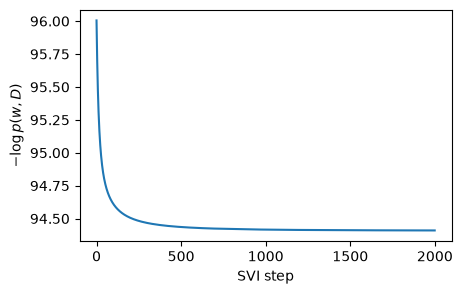

In [15]:
pyro.clear_param_store()

delta_guide = AutoLaplaceApproximation(
    ll_model, init_loc_fn=init_to_value(values={"w": w_map})
)
svi = SVI(ll_model, delta_guide, pyro.optim.Adam({"lr": 1e-2}), loss=Trace_ELBO())

laplace_losses = [svi.step(X_train, y_train) for _ in range(2000)]
print(f"neg. log joint at MAP: {laplace_losses[-1]:.3f}")

plt.figure(figsize=(4.8, 3))
plt.plot(laplace_losses)
plt.xlabel("SVI step"); plt.ylabel(r"$-\log p(w, D)$")

In [16]:
guide = delta_guide.laplace_approximation(X_train, y_train)

posterior = guide.get_posterior()          # MultivariateNormal over w
loc = posterior.mean                       # (h,)
Sigma = posterior.covariance_matrix        # (h, h)

print("||loc - w_map||:", (loc - w_map).norm().item())
print("posterior std (first 5):", posterior.stddev[:5].numpy().round(4))

||loc - w_map||: 5.161323511949865
posterior std (first 5): [40.3196 39.7796 39.8695 28.0709 38.5653]


### Predict

Two equivalent routes. The **probit approximation** (MacKay 1992) is the one
`bnn_laplace.ipynb` uses and is closed form:

$$p(y=1 \mid x) \approx \sigma\!\left(\frac{m(x)}{\sqrt{1 + \tfrac{\pi}{8} v(x)}}\right),
\quad m = \phi(x)^\top \mu, \; v = \phi(x)^\top \Sigma \, \phi(x).$$

The **Monte Carlo** route averages *probabilities*, not logits. Averaging logits
first and then applying the sigmoid — `samples["logits"].mean(0).sigmoid()` —
throws the whole marginalisation away and gives you the MAP prediction back;
that is the single most common way this plot comes out looking unchanged.

In [17]:
phi_test = features(X_test)

# Closed-form probit approximation
mu_test = phi_test @ loc
v_test = torch.einsum("ni,ij,nj->n", phi_test, Sigma, phi_test)
py_probit = torch.sigmoid(mu_test / torch.sqrt(1 + math.pi / 8 * v_test))

# Monte Carlo: average the *probabilities*
predictive = Predictive(ll_model, guide=guide, num_samples=2000,
                        return_sites=("logits",))
py_mc = predictive(X_test, None)["logits"].sigmoid().mean(0)

py_map = torch.sigmoid(mu_test)            # plug-in MAP, for comparison

print(f"max |probit - MC| = {(py_probit - py_mc).abs().max():.4f}")

max |probit - MC| = 0.0420


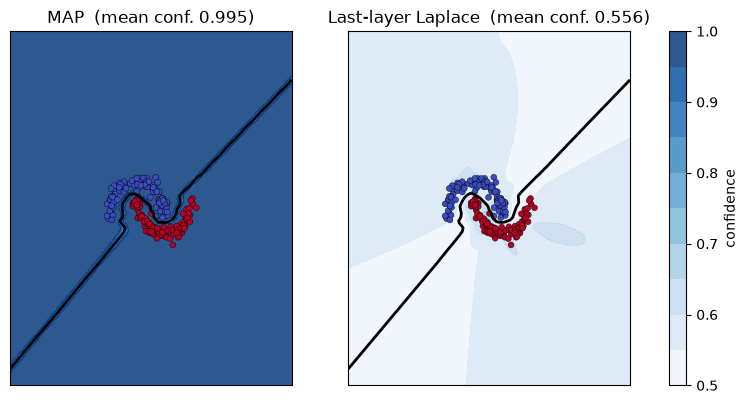

In [18]:
def conf(p: Tensor) -> Tensor:
    return torch.maximum(p, 1 - p).reshape(X1.shape).detach()


fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
for ax, p, title in zip(axes, (py_map, py_probit), ("MAP", "Last-layer Laplace")):
    im = ax.contourf(X1, X2, conf(p), levels=np.arange(0.5, 1.01, 0.05),
                     cmap="Blues", vmin=0.5, vmax=1.0, alpha=0.85)
    ax.contour(X1, X2, p.reshape(X1.shape).detach(), levels=[0.5],
               colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=18, edgecolors="k",
               linewidths=0.3)
    ax.set_title(f"{title}  (mean conf. {conf(p).mean():.3f})")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, label="confidence")

### Sanity check against the explicit Hessian

Evaluated at the same $w$, Pyro's Laplace covariance and the `exact_hessian`
route from `bnn_laplace.ipynb` agree to machine precision.

In [19]:
from hessian import exact_hessian

W = model.clf.weight
W.data = loc.reshape(W.shape).clone()
W.requires_grad_(True)

nll = F.binary_cross_entropy_with_logits(model(X_train).squeeze(), y_train, reduction="sum")
nlp = 0.5 * W.flatten() @ (1 / prior_var * torch.eye(W.numel())) @ W.flatten()
Sigma_ref = torch.inverse(exact_hessian(nll + nlp, [W]))

rel = ((Sigma - Sigma_ref).norm() / Sigma_ref.norm()).item()
print(f"relative difference: {rel:.2e}")

W.requires_grad_(False)

relative difference: 7.86e-16


Parameter containing:
tensor([[-1.4041, -1.4953, -1.2762, -2.0593,  0.7341,  2.0411,  2.3922,  1.3979,
         -1.3871,  4.2372,  1.1354, -1.5614,  1.0182, -1.1430,  1.5351, -1.5981,
         -0.5105, -1.3445, -1.3448, -1.9393]])